In [269]:
import torch
from diffusers import AutoPipelineForText2Image

device = "mps" if torch.backends.mps.is_available() else "cpu"

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16 if device == "mps" else torch.float32,
    variant="fp16" if device == "mps" else None,
)

pipe = pipe.to(device)

def build_sticker_prompt(query: str) -> str:
    return (
        f"{query}, cartoon/animated illustration, ONLY ONE centered object, "
        "plain white background, clean, high quality"
    )

def generate_image(query: str):
    prompt = build_sticker_prompt(query)

    image = pipe(
        prompt=prompt,
        num_inference_steps=4,
        guidance_scale=0.0,
        width=512,
        height=512,
    ).images[0]

    return image

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.15it/s]


100%|██████████| 4/4 [00:01<00:00,  2.43it/s]


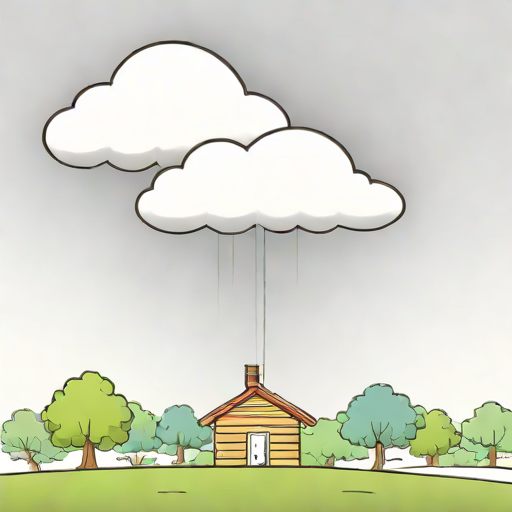

In [271]:
img = generate_image("sad weather today")
img

100%|██████████| 4/4 [00:01<00:00,  2.35it/s]


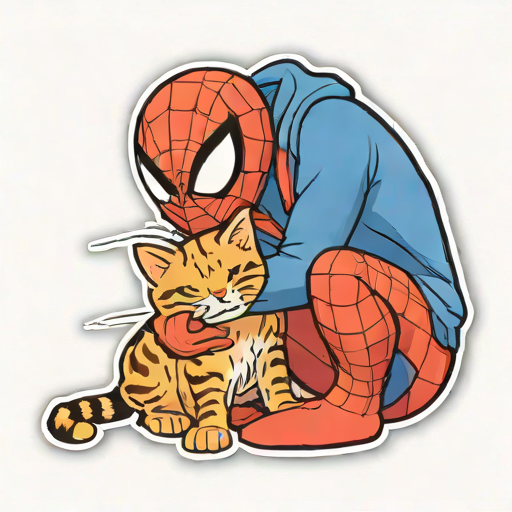

In [268]:
def build_sticker_prompt(query: str) -> str:
    return (
        f"A single isolated sticker of {query}. "
        "Exactly one main subject, centered in the image, full body visible. "
        "No other characters, no extra faces, no icons, no repeated objects, "
        "no sticker sheet, no collage, no background elements. "
        "Plain white background, clean outline, simple composition."
    )

def generate_image(query: str):
    prompt = build_sticker_prompt(query)

    image = pipe(
        prompt=prompt,
        negative_prompt = (
            "multiple characters, many objects, sticker sheet, collage, grid, icons, "
            "repeated faces, extra heads, extra people, background scene, decorations, "
            "text, letters, watermark, logo, clutter, cropped body, cut off"
        ),
        num_inference_steps=4,
        guidance_scale=0.0,
    ).images[0]

    return image

img = generate_image("spiderman kissing a cat")
img

100%|██████████| 4/4 [00:01<00:00,  2.34it/s]


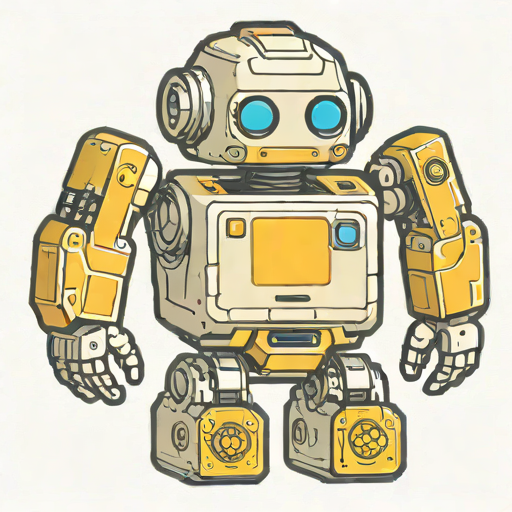

In [265]:
img = generate_image("programming ai")
img